In [196]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('/Users/simar/Downloads/Book1 (3).csv')

In [197]:
df.head(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN


## Data Cleaning 

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [199]:
#percentage of missing values in each column
print(df.isnull().sum()/df.shape[0]*100)

v1             0.000000
v2             0.000000
Unnamed: 2    99.102656
Unnamed: 3    99.784637
Unnamed: 4    99.892319
dtype: float64


In [200]:
#dropping last three columns because they have more than 50% missing values
df=df.iloc[:,0:2]
print(df.head())

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [201]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
print(df.head())

  target                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...


In [202]:
#feature scaling
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['target']=le.fit_transform(df['target'])
print(df.head())

   target                                               text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...


In [203]:
#checking and removing duplicates
df.duplicated().sum()
df= df.drop_duplicates(keep='first')
print(df.duplicated().sum())
print(df.shape)

0
(5169, 2)


## EDA


In [204]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/simar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [205]:
#counting no. of characters in each text
df['num_characters']=df['text'].apply(len)
print(df.head())

   target                                               text  num_characters
0       0  Go until jurong point, crazy.. Available only ...             111
1       0                      Ok lar... Joking wif u oni...              29
2       1  Free entry in 2 a wkly comp to win FA Cup fina...             155
3       0  U dun say so early hor... U c already then say...              49
4       0  Nah I don't think he goes to usf, he lives aro...              61


In [206]:
df['num_words']= df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
print(df.head())

   target                                               text  num_characters  \
0       0  Go until jurong point, crazy.. Available only ...             111   
1       0                      Ok lar... Joking wif u oni...              29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...             155   
3       0  U dun say so early hor... U c already then say...              49   
4       0  Nah I don't think he goes to usf, he lives aro...              61   

   num_words  num_sentences  
0         24              2  
1          8              2  
2         37              2  
3         13              1  
4         15              1  


In [207]:
# data stats 
stat= df.iloc[:,2:].describe()
print (stat) 

       num_characters    num_words  num_sentences
count     5169.000000  5169.000000    5169.000000
mean        78.977945    18.455794       1.965564
std         58.236293    13.324758       1.448541
min          2.000000     1.000000       1.000000
25%         36.000000     9.000000       1.000000
50%         60.000000    15.000000       1.000000
75%        117.000000    26.000000       2.000000
max        910.000000   220.000000      38.000000


In [208]:
print("ham messages")
df[df['target']==0].iloc[:,2:].describe()

ham messages


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [209]:
print("spam messages")
df[df['target']==1].iloc[:,2:].describe()

spam messages


,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


## Data analyzing using visualization

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

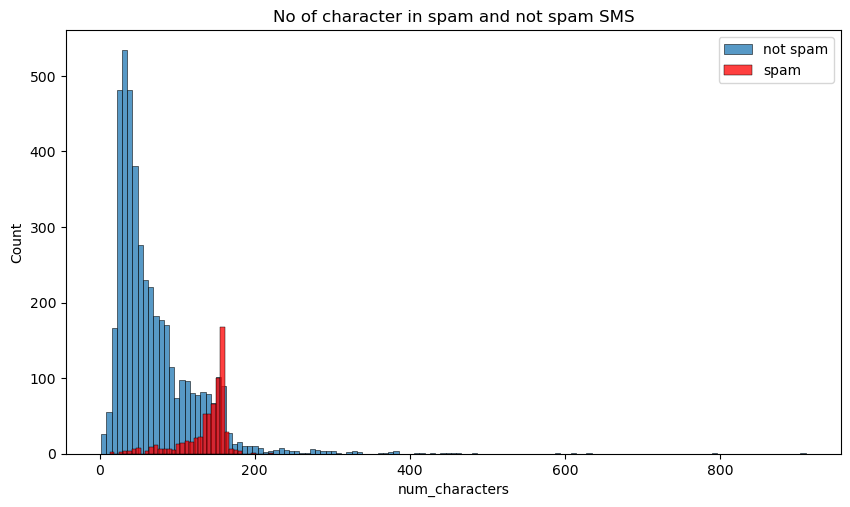

In [211]:
plt.figure(figsize=(10,5.5))
plt.title('No of character in spam and not spam SMS')
sns.histplot(df[df['target']==0].iloc[:,2],label='not spam')
sns.histplot(df[df['target']==1].iloc[:,2],color='red',label='spam')
plt.legend()
plt.show()

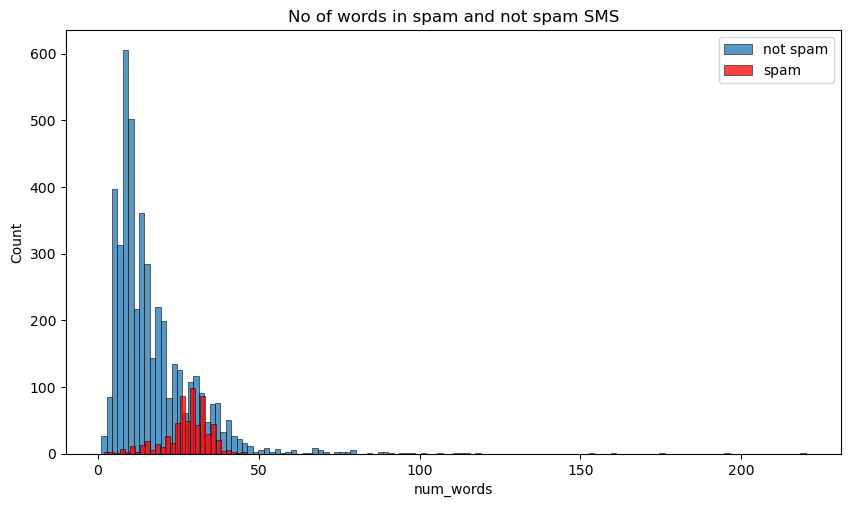

In [212]:
plt.figure(figsize=(10,5.5))
plt.title('No of words in spam and not spam SMS')
sns.histplot(df[df['target']==0].iloc[:,3],label='not spam')
sns.histplot(df[df['target']==1].iloc[:,3],color='red',label='spam')
plt.legend()
plt.show()

<Axes: >

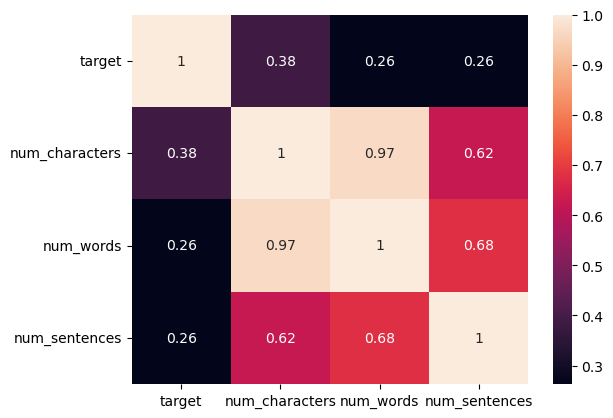

In [213]:
num_rows=df.select_dtypes(include=np.number)
sns.heatmap(num_rows.corr(),annot=True)

#spam sms are typically longer (more words and characters) than non-spam sms, making message length a useful feature for classification.

## Data Preprocessing
- Lower case 
- Tokenization
- Removing special characters
- Stop words and punctuation removal
- Stemming

In [214]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')

from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

import string
string.punctuation

[nltk_data] Downloading package stopwords to /Users/simar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [215]:
def transform_text(text):
    text=text.lower()# converting in lower case
    # print(text)
    text=nltk.word_tokenize(text)# splitting into words
    # print(text)
    # removing special characters
    L=[]
    for i in text:
        if i.isalnum():
            L.append(i)
    # print(L)
    
# # # #     # removing stop words and punctuation marks
    text=L.copy()
    L.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            L.append(i)
    # print(L)
# # # #     # applying stemming
    text=L.copy()
    L.clear()
    for i in text:
        L.append(ps.stem(i))
    # print(L)
        
    return " ".join(L)

In [216]:
df['transformed_text']=df['text'].apply(transform_text)
print(df.head())

   target                                               text  num_characters  \
0       0  Go until jurong point, crazy.. Available only ...             111   
1       0                      Ok lar... Joking wif u oni...              29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...             155   
3       0  U dun say so early hor... U c already then say...              49   
4       0  Nah I don't think he goes to usf, he lives aro...              61   

   num_words  num_sentences                                   transformed_text  
0         24              2  go jurong point crazi avail bugi n great world...  
1          8              2                              ok lar joke wif u oni  
2         37              2  free entri 2 wkli comp win fa cup final tkt 21...  
3         13              1                u dun say earli hor u c alreadi say  
4         15              1               nah think goe usf live around though  


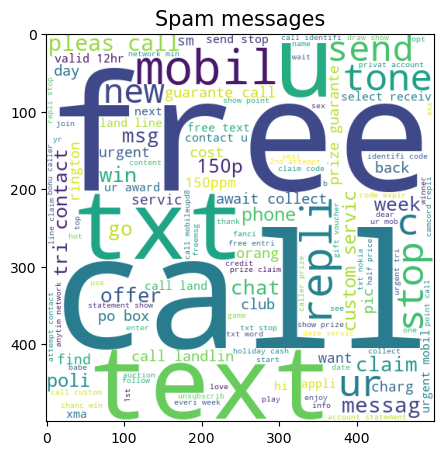

In [217]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" ")) #spam messages(1)
plt.figure(figsize=(5,8),dpi=100)
plt.title('Spam messages',fontsize=15)
plt.imshow(spam_wc);

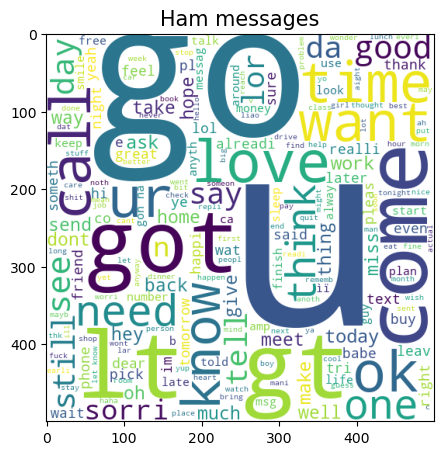

In [218]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep='" "'))
plt.figure(figsize=(5,8),dpi=100)
plt.title('Ham messages',fontsize=15)
plt.imshow(ham_wc);

# Spam corpus

In [219]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        
print(spam_corpus) 

['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', '21st', 'may', 'text', 'fa', '87121', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli', '08452810075over18', 'freemsg', 'hey', 'darl', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chg', 'send', 'rcv', 'winner', 'valu', 'network', 'custom', 'select', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hour', 'mobil', '11', 'month', 'u', 'r', 'entitl', 'updat', 'latest', 'colour', 'mobil', 'camera', 'free', 'call', 'mobil', 'updat', 'co', 'free', '08002986030', 'six', 'chanc', 'win', 'cash', '100', 'pound', 'txt', 'csh11', 'send', 'cost', '6day', 'tsandc', 'appli', 'repli', 'hl', '4', 'info', 'urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18', 'xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'click',

In [220]:
from collections import Counter
spam_df=pd.DataFrame(Counter(spam_corpus).most_common()).rename(columns={0:'words',1:'count'})
spam_df

,words,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
...,...,...
2217,shit,1
2218,bailiff,1
2219,hous,1
2220,087187272008,1


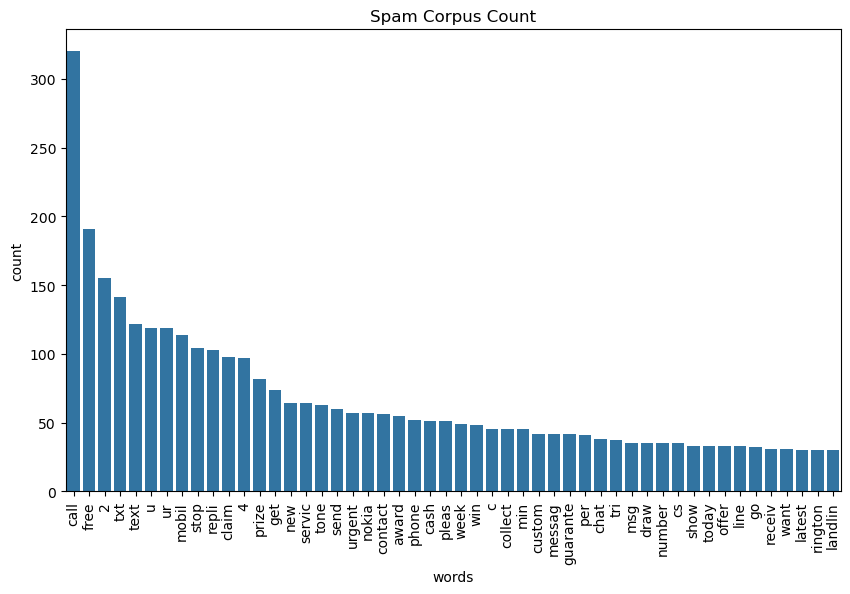

In [221]:
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=spam_df.head(50))
plt.xticks(rotation='vertical')
plt.title('Spam Corpus Count')
plt.show()

# Ham Corpus

In [222]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
print(ham_corpus)

['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'wat', 'ok', 'lar', 'joke', 'wif', 'u', 'oni', 'u', 'dun', 'say', 'earli', 'hor', 'u', 'c', 'alreadi', 'say', 'nah', 'think', 'goe', 'usf', 'live', 'around', 'though', 'even', 'brother', 'like', 'speak', 'treat', 'like', 'aid', 'patent', 'per', 'request', 'mell', 'oru', 'minnaminungint', 'nurungu', 'vettam', 'set', 'callertun', 'caller', 'press', '9', 'copi', 'friend', 'callertun', 'gon', 'na', 'home', 'soon', 'want', 'talk', 'stuff', 'anymor', 'tonight', 'k', 'cri', 'enough', 'today', 'search', 'right', 'word', 'thank', 'breather', 'promis', 'wont', 'take', 'help', 'grant', 'fulfil', 'promis', 'wonder', 'bless', 'time', 'date', 'sunday', 'oh', 'k', 'watch', 'eh', 'u', 'rememb', '2', 'spell', 'name', 'ye', 'v', 'naughti', 'make', 'v', 'wet', 'fine', 'thatåõ', 'way', 'u', 'feel', 'thatåõ', 'way', 'gota', 'b', 'serious', 'spell', 'name', 'go', 'tri', '2', 'month', 'ha', 

In [223]:
ham_df=pd.DataFrame(Counter(ham_corpus).most_common()).rename(columns={0:'words',1:'count'})
ham_df

,words,count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
...,...,...
5385,nmde,1
5386,dump,1
5387,heap,1
5388,salesman,1


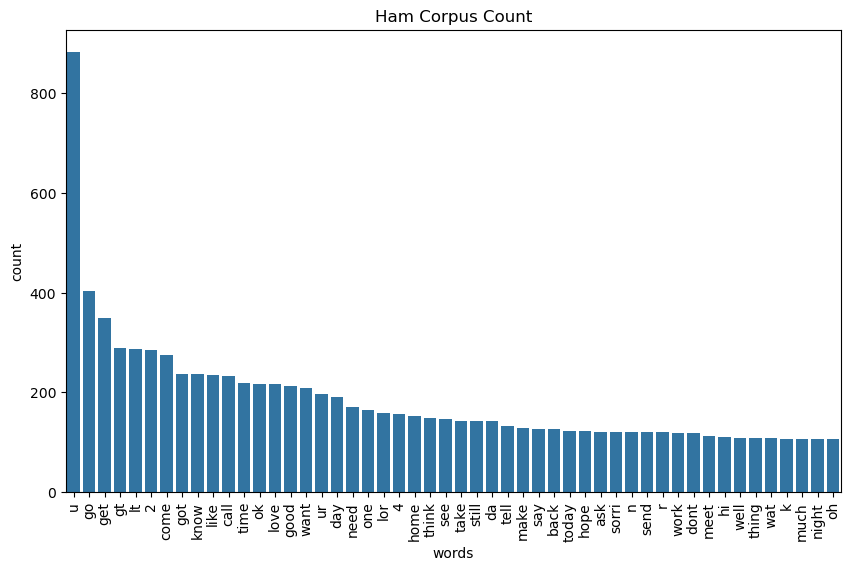

In [224]:
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=ham_df.head(50))
plt.xticks(rotation='vertical')
plt.title('Ham Corpus Count')
plt.show()

## Feature Engineering 

In [2]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [226]:
X=tfidf.fit_transform(df['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [227]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [228]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

## Model Building 

In [229]:
!pip install xgboost

101011.86s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [230]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [231]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [232]:
gnb.fit(x_train,y_train)
y_pred_test1=gnb.predict(x_test)
y_pred_train1=gnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test1))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train1))
print('Precision_Score',precision_score(y_train,y_pred_train1))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train1))

""" TP   FN
    FP   TN """

Testing Accuracy 0.8694390715667312
Trainning_Accuracy 0.8931076178960097
Precision_Score 0.5381400208986415
Confusion_matrix
 [[3178  442]
 [   0  515]]


' TP   FN\n    FP   TN '

In [233]:
mnb.fit(x_train,y_train)
y_pred_test2=mnb.predict(x_test)
y_pred_train2=mnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test2))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train2))
print('Precision_Score',precision_score(y_train,y_pred_train2))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train2))

Testing Accuracy 0.9709864603481625
Trainning_Accuracy 0.9789600967351875
Precision_Score 0.9953703703703703
Confusion_matrix
 [[3618    2]
 [  85  430]]


In [234]:
bnb.fit(x_train,y_train)
y_pred_test3=bnb.predict(x_test)
y_pred_train3=bnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test3))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train3))
print('Precision_Score',precision_score(y_train,y_pred_train3))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train3))

Testing Accuracy 0.9835589941972921
Trainning_Accuracy 0.9857315598548972
Precision_Score 0.9935064935064936
Confusion_matrix
 [[3617    3]
 [  56  459]]


In [235]:
svc = SVC()
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [236]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [245]:
def train_classifier(clf, X_train, y_train, X_test, y_test):

    clf.fit(X_train, y_train)

    y_pred_test = clf.predict(X_test)
    y_pred_train = clf.predict(X_train)

    accuracy_test = accuracy_score(y_test, y_pred_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)

    precision = precision_score(y_test, y_pred_test)

    return accuracy_test, accuracy_train, precision

In [246]:
train_classifier(SVC(),x_train,y_train,x_test,y_test)

(0.9729206963249516, 0.9963724304715841, 0.9824561403508771)

In [247]:
accuracy_train1 = []
accuracy_test1 = []
precision_scores = []

for name, clf in clfs.items():

    accuracy_test, accuracy_train, precision = train_classifier(
        clf,
        x_train,
        y_train,
        x_test,
        y_test
    )

    print("For", name)
    print("Training Accuracy :", accuracy_train)
    print("Testing Accuracy  :", accuracy_test)
    print("Precision Score   :", precision)
    print()

    accuracy_train1.append(accuracy_train)
    accuracy_test1.append(accuracy_test)
    precision_scores.append(precision)

For SVC
Training Accuracy : 0.9963724304715841
Testing Accuracy  : 0.9729206963249516
Precision Score   : 0.9824561403508771

For KN
Training Accuracy : 0.9257557436517533
Testing Accuracy  : 0.9052224371373307
Precision Score   : 1.0

For NB
Training Accuracy : 0.9789600967351875
Testing Accuracy  : 0.9709864603481625
Precision Score   : 1.0

For DT
Training Accuracy : 0.9496977025392986
Testing Accuracy  : 0.9294003868471954
Precision Score   : 0.8282828282828283

For LR
Training Accuracy : 0.965659008464329
Testing Accuracy  : 0.9564796905222437
Precision Score   : 0.979381443298969

For RF
Training Accuracy : 0.999758162031439
Testing Accuracy  : 0.9758220502901354
Precision Score   : 0.9829059829059829

For AdaBoost
Training Accuracy : 0.9255139056831923
Testing Accuracy  : 0.9245647969052224
Precision Score   : 0.8488372093023255

For BgC
Training Accuracy : 0.9990326481257558
Testing Accuracy  : 0.9584139264990329
Precision Score   : 0.8682170542635659

For ETC
Training Accuracy

In [248]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_train': accuracy_train1,
    'Accuracy_test': accuracy_test1,
    'Precision_score': precision_scores
})

performance_df = performance_df.sort_values(
    by='Precision_score',
    ascending=False
)

print(performance_df)

   Algorithm  Accuracy_train  Accuracy_test  Precision_score
1         KN        0.925756       0.905222         1.000000
2         NB        0.978960       0.970986         1.000000
5         RF        0.999758       0.975822         0.982906
0        SVC        0.996372       0.972921         0.982456
4         LR        0.965659       0.956480         0.979381
8        ETC        0.999758       0.974855         0.974576
10       xgb        0.984281       0.970019         0.949580
9       GBDT        0.967110       0.946809         0.919192
7        BgC        0.999033       0.958414         0.868217
6   AdaBoost        0.925514       0.924565         0.848837
3         DT        0.949698       0.929400         0.828283


Selecting Multinomial Naive Bayes (MNB) as the final model because it achieved the highest precision score (1.00) while also maintaining a high testing accuracy (97.09%). Although KNN also obtained a precision score of 1.00, its testing accuracy was significantly lower (90.52%). Therefore, MNB provides a better balance between precision and overall performance for SMS spam classification.

In [249]:
best_model = mnb

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

print("Best Model : Multinomial Naive Bayes")

print("Testing Accuracy :", accuracy_score(y_test, y_pred))

print("Precision Score :", precision_score(y_test, y_pred))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred))

Best Model : Multinomial Naive Bayes
Testing Accuracy : 0.9709864603481625
Precision Score : 1.0
Confusion Matrix :
[[896   0]
 [ 30 108]]


In [250]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))